In [1]:
from BGN_LNG.Utils.utils_spark import *

# Insert file path to your client credentials here
client_id, client_secret = retrieve_credentials(file_path="client_credentials.csv")

# Authenticate:
access_token = get_access_token(client_id, client_secret)

>>>> Found credentials!
>>>> Client_id=d0953****, client_secret=601d8****
>>>> Successfully fetched an access token eyJhb****, valid 604799 seconds.


In [6]:
full_df = fetch_cargo_prices(access_token, 'sparknwe', 30*30, month="M+2")
full_df

/v1.0/contracts/sparknwe-b-fo/price-releases/?limit=900
Fetching https://api.sparkcommodities.com/v1.0/contracts/sparknwe-b-fo/price-releases/?limit=900


,Release Date,ticker,Period Start,Price
0,2025-12-18,sparknwe-b-fo,2026-02-01,-0.515
1,2025-12-11,sparknwe-b-fo,2026-02-01,-0.520
2,2025-12-04,sparknwe-b-fo,2026-02-01,-0.490
3,2025-11-27,sparknwe-b-fo,2026-01-01,-0.490
4,2025-11-20,sparknwe-b-fo,2026-01-01,-0.500
...,...,...,...,...
230,2021-06-24,sparknwe-b-fo,2021-09-01,0.030
231,2021-06-17,sparknwe-b-fo,2021-09-01,0.025
232,2021-06-10,sparknwe-b-fo,2021-09-01,-0.005
233,2021-06-03,sparknwe-b-fo,2021-09-01,0.120


In [2]:
import pandas as pd
month = 'M+1'
loops = 30

# Import NWE/SWE LNG prices
full_df = fetch_cargo_prices(access_token, 'sparknwe', loops*30, month=month)
# sparkswe = cargo_to_dataframe(access_token, 'sparkswe', loops*30, month=month)
full_df = full_df.rename(columns={'Price': month})
m_cols_list = [month]


for m in range(2, 13):
    month = "M+" + str(m)
    sparknwe_m = fetch_cargo_prices(access_token, 'sparknwe', loops*30, month=month)
    full_df = pd.merge(full_df, sparknwe_m, how='left', on='Release Date')
    full_df = full_df[['Release Date'] + m_cols_list + ['Price']].copy()
    full_df = full_df.rename(columns={'Price': month})
    m_cols_list.append(month)

# retrieve the same amount of historical data for SparkSWE as SparkNWE
# sparkswe = sparkswe[sparkswe['Release Date'] >= sparknwe['Release Date'].iloc[-1]].copy()

# Combine datasets and backfill SWE data as needed (due to reduced assessment frequency)
# cargo_df = pd.merge(sparknwe, sparkswe, how='left', on='Release Date')

# cargo_df['Price_y'] = cargo_df['Price_y'].bfill().copy()

# cargo_df = cargo_df[['Release Date', 'Price_x', 'Price_y']].copy()
# cargo_df = cargo_df.rename(columns={'Price_x': 'SparkNWE',
#                                     'Price_y': 'SparkSWE'})




/v1.0/contracts/sparknwe-b-f/price-releases/?limit=900
Fetching https://api.sparkcommodities.com/v1.0/contracts/sparknwe-b-f/price-releases/?limit=900
/v1.0/contracts/sparknwe-b-fo/price-releases/?limit=900
Fetching https://api.sparkcommodities.com/v1.0/contracts/sparknwe-b-fo/price-releases/?limit=900
/v1.0/contracts/sparknwe-b-fo/price-releases/?limit=900
Fetching https://api.sparkcommodities.com/v1.0/contracts/sparknwe-b-fo/price-releases/?limit=900
/v1.0/contracts/sparknwe-b-fo/price-releases/?limit=900
Fetching https://api.sparkcommodities.com/v1.0/contracts/sparknwe-b-fo/price-releases/?limit=900
/v1.0/contracts/sparknwe-b-fo/price-releases/?limit=900
Fetching https://api.sparkcommodities.com/v1.0/contracts/sparknwe-b-fo/price-releases/?limit=900
/v1.0/contracts/sparknwe-b-fo/price-releases/?limit=900
Fetching https://api.sparkcommodities.com/v1.0/contracts/sparknwe-b-fo/price-releases/?limit=900
/v1.0/contracts/sparknwe-b-fo/price-releases/?limit=900
Fetching https://api.sparkco

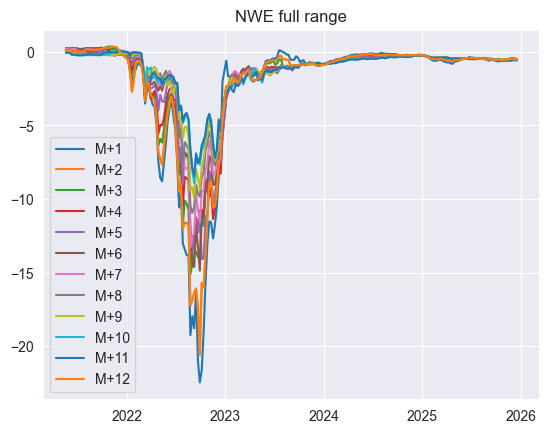

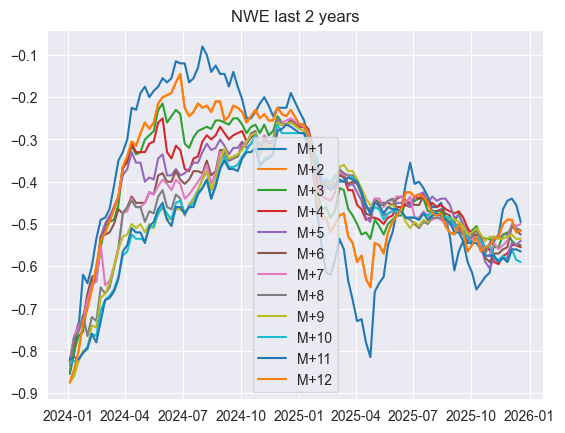

In [3]:
from datetime import date
import matplotlib.pyplot as plt
full_df_nona = full_df.dropna()
full_df_nona.set_index("Release Date", inplace=True)
full_df_nona.index = [d.date() for d in full_df_nona.index]
full_df_nona.index.name = None
full_df_nona.plot(title="NWE full range")
plt.show()
last_2years = full_df_nona[full_df_nona.index > date(2024, 1, 1)]
last_2years.plot(title="NWE last 2 years")
plt.show()



In [6]:
last_2years["M+12"].shift(1)

2025-12-18      NaN
2025-12-11   -0.515
2025-12-04   -0.520
2025-11-27   -0.490
2025-11-20   -0.490
              ...  
2024-02-01   -0.655
2024-01-25   -0.700
2024-01-18   -0.735
2024-01-11   -0.800
2024-01-04   -0.845
Name: M+12, Length: 102, dtype: float64

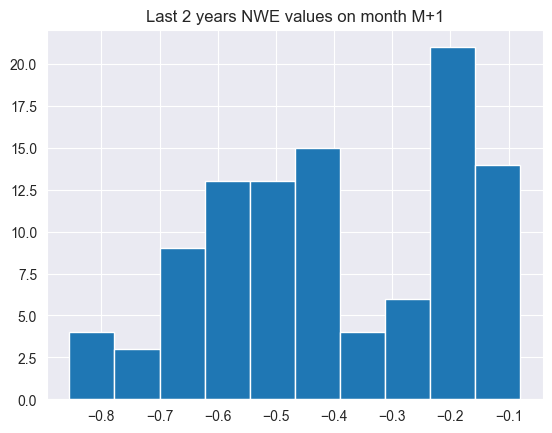

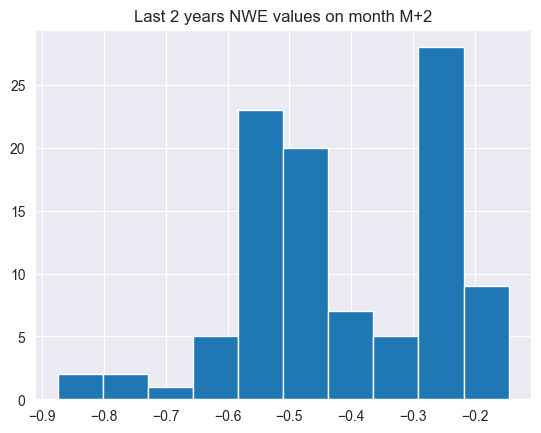

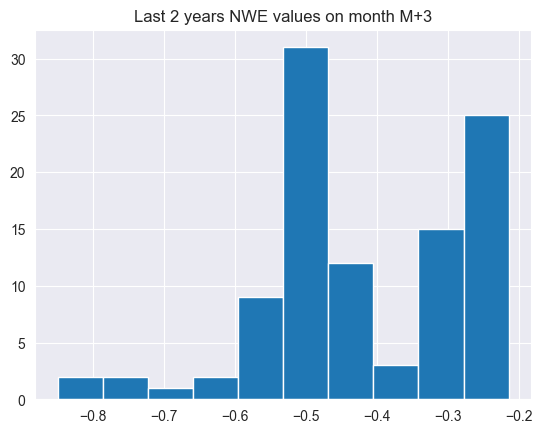

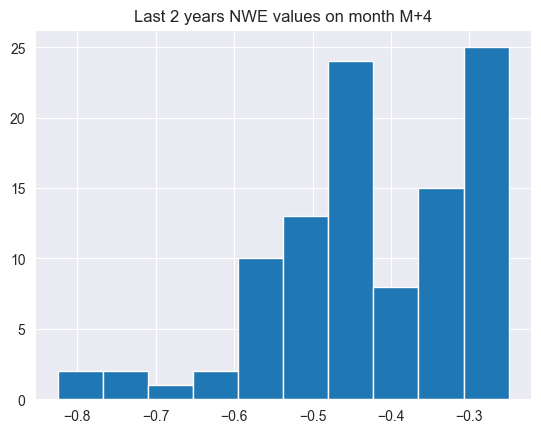

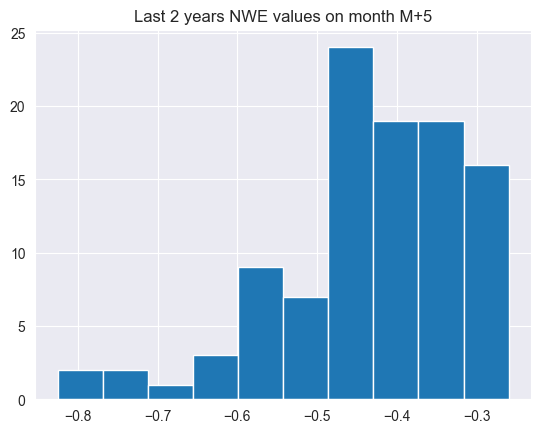

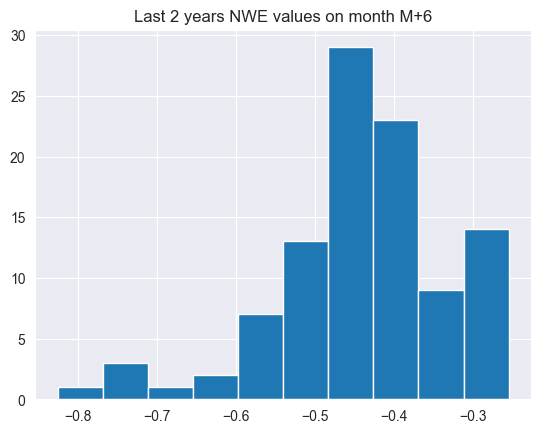

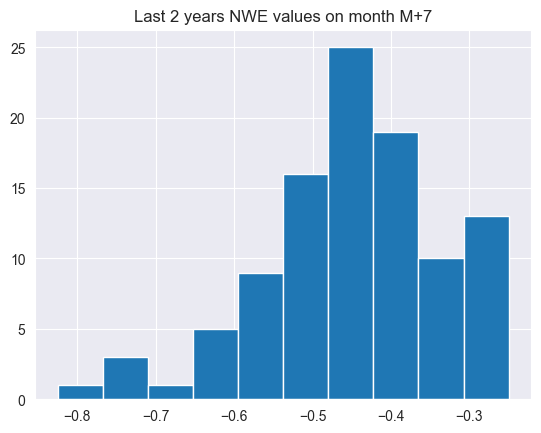

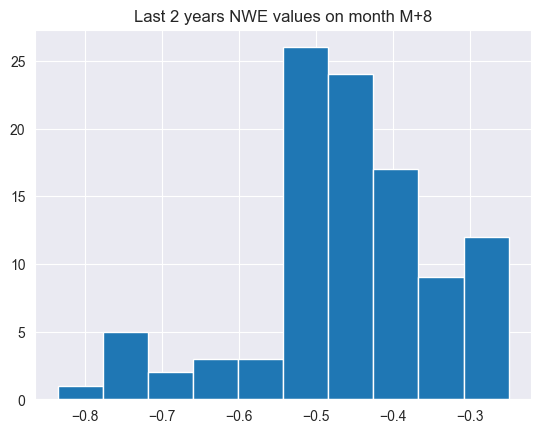

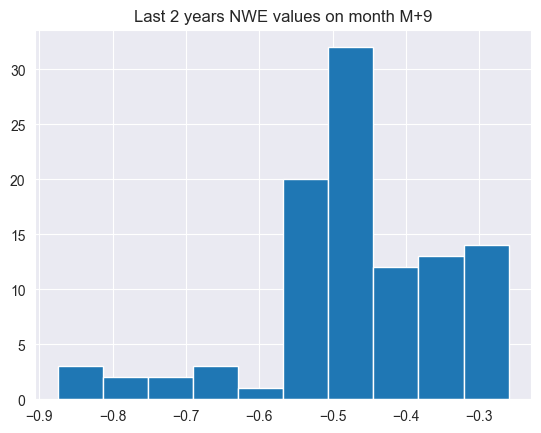

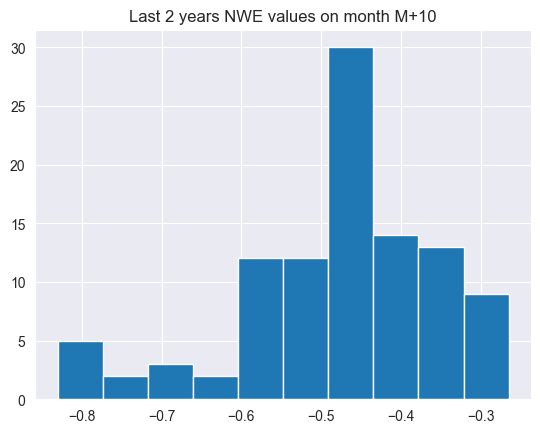

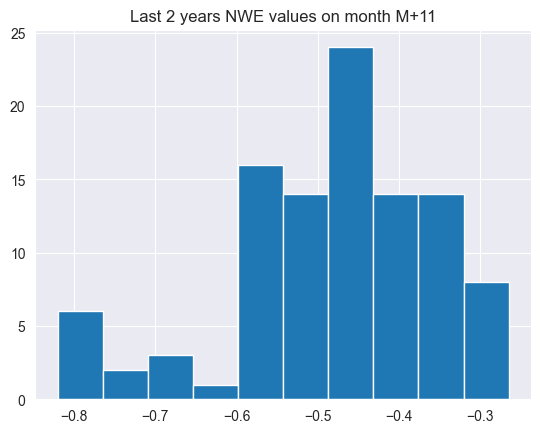

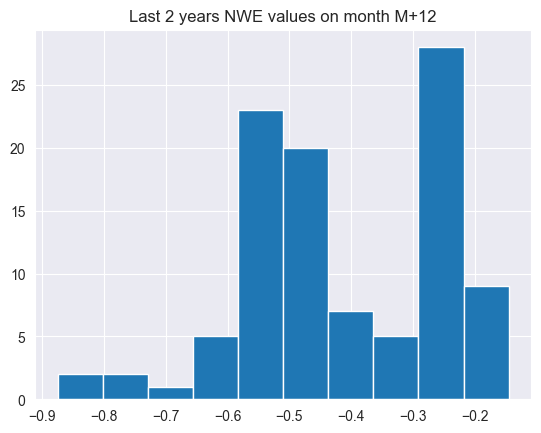

In [12]:
import matplotlib.pyplot as plt
diff_nwe = last_2years - last_2years.shift(-1)
diff_nwe.dropna(inplace=True)
# for i in range(12):
#     diff_nwe[diff_nwe.columns[i]].hist()
#     plt.title("NWE diffs on month " + diff_nwe.columns[i])
#     plt.show()

for i in range(12):
    last_2years[last_2years.columns[i]].hist()
    plt.title("Last 2 years NWE values on month " + last_2years.columns[i])
    plt.show()

<Axes: >

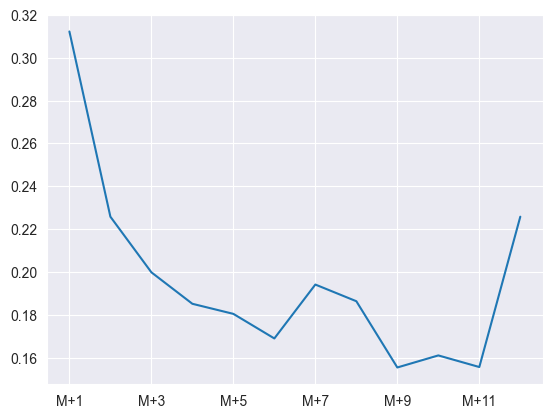

In [9]:
import numpy as np
(np.sqrt(52)*diff_nwe.std()).plot()

-0.39929963176804645


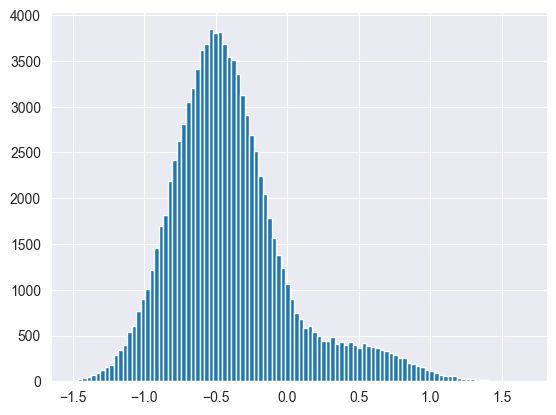

In [8]:
from BGN_LNG.Utils.utils_maths import *
import matplotlib.pyplot as plt

n = 100000
bnwe = truncated_normal_sample(n, -1.5, 0.5, -0.5, sigma=0.3)
jump = jump_rv(n, p=0.1, mu=1.0, sigma=0.1)

x = bnwe + jump
print(x.mean())
plt.hist(x, bins=100);